In [4]:
import pandas as pd
import numpy as np

# 1. Load the data

df = pd.read_csv('/kaggle/global_ai_tech_layoffs_2020_2026.csv')
# 2. Convert Date column to official Datetime format
df['date_announced'] = pd.to_datetime(df['date_announced'])

# 3. Clean string columns (removing accidental spaces)
text_columns = ['company', 'industry', 'hq_country', 'hq_city']
for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

# 4. Check for duplicates
duplicate_count = df.duplicated().sum()
print(f"Removed {duplicate_count} duplicate rows.")
df = df.drop_duplicates()

# 5. Save the cleaned version
df.to_csv('/kaggle/cleaned_layoffs_data.csv', index=False)
print("Data is now cleaned and standardized!")

#6. Download the cleaned files for record
from google.colab import files
files.download('/kaggle/cleaned_layoffs_data.csv')

Removed 0 duplicate rows.
Data is now cleaned and standardized!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Top Countries by "AI vs Traditional"

# 1. Group by country and the AI flag
country_comparison = df.groupby(['hq_country', 'is_ai_related_layoff'])['number_laid_off'].sum().unstack(fill_value=0)

# 2. Rename columns for your portfolio report
country_comparison.columns = ['Traditional', 'AI_Driven']


# 3 Calculate Total and AI-Driven Percentage
country_comparison['Total'] = country_comparison['Traditional'] + country_comparison['AI_Driven']
country_comparison['AI_Driven_Pct'] = (country_comparison['AI_Driven'] / country_comparison['Total']) * 100

# 4. Sort by Total Layoffs to see the biggest impact
top_countries = country_comparison.sort_values('Total', ascending=False).head(10)

# 5. See the Top 5
country_comparison.sort_values('Total', ascending=False).head(5)

# Display the table (Formatted for report)
print("--- Global AI Reset: Country Breakdown ---")
print(top_countries[['Total', 'AI_Driven_Pct']].round(2))

--- Global AI Reset: Country Breakdown ---
                 Total  AI_Driven_Pct
hq_country                           
United States  4576663          27.10
India          1090477          15.75
China           759793          20.64
Germany         691349          28.95
South Korea     346570          20.43
Japan           184345          13.89
Netherlands     164492          32.37
Sweden          134136          10.06
Singapore       119143          46.01
Argentina        56809          24.55


In [ ]:
country_comparison

,Traditional,AI_Driven,Total,AI_Driven_Pct
hq_country,,,,
Argentina,42863,13946,56809,24.548927
Australia,16747,5928,22675,26.143330
Brazil,6462,1829,8291,22.060065
Canada,12944,2095,15039,13.930448
China,602938,156855,759793,20.644439
Colombia,5912,149,6061,2.458340
Estonia,2122,962,3084,31.193256
France,277,80,357,22.408964
Germany,491233,200116,691349,28.945728


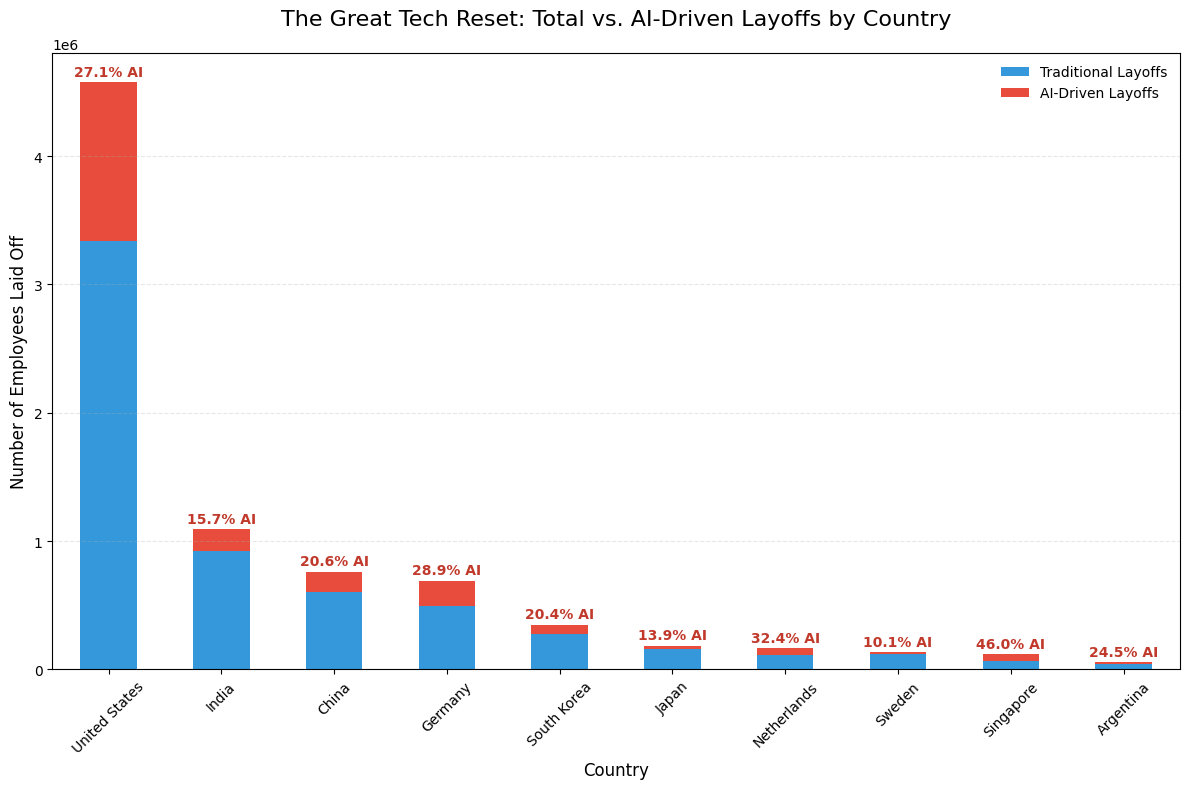

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5. Create the Visualization
plt.figure(figsize=(12, 8))

# We use the top_countries dataframe we just created
# [False] = Traditional Layoffs, [True] = AI-Driven Layoffs
top_countries[['Traditional', 'AI_Driven']].plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c'], ax=plt.gca())

# Adding Labels and Styling
plt.title('The Great Tech Reset: Total vs. AI-Driven Layoffs by Country', fontsize=16, pad=20)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Employees Laid Off', fontsize=12)
plt.legend(['Traditional Layoffs', 'AI-Driven Layoffs'], frameon=False)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add percentage annotations on top of the bars
for i, (total, pct) in enumerate(zip(top_countries['Total'], top_countries['AI_Driven_Pct'])):
    plt.text(i, total + 50000, f'{pct:.1f}% AI', ha='center', fontsize=10, fontweight='bold', color='#c0392b')

plt.tight_layout()
plt.show()

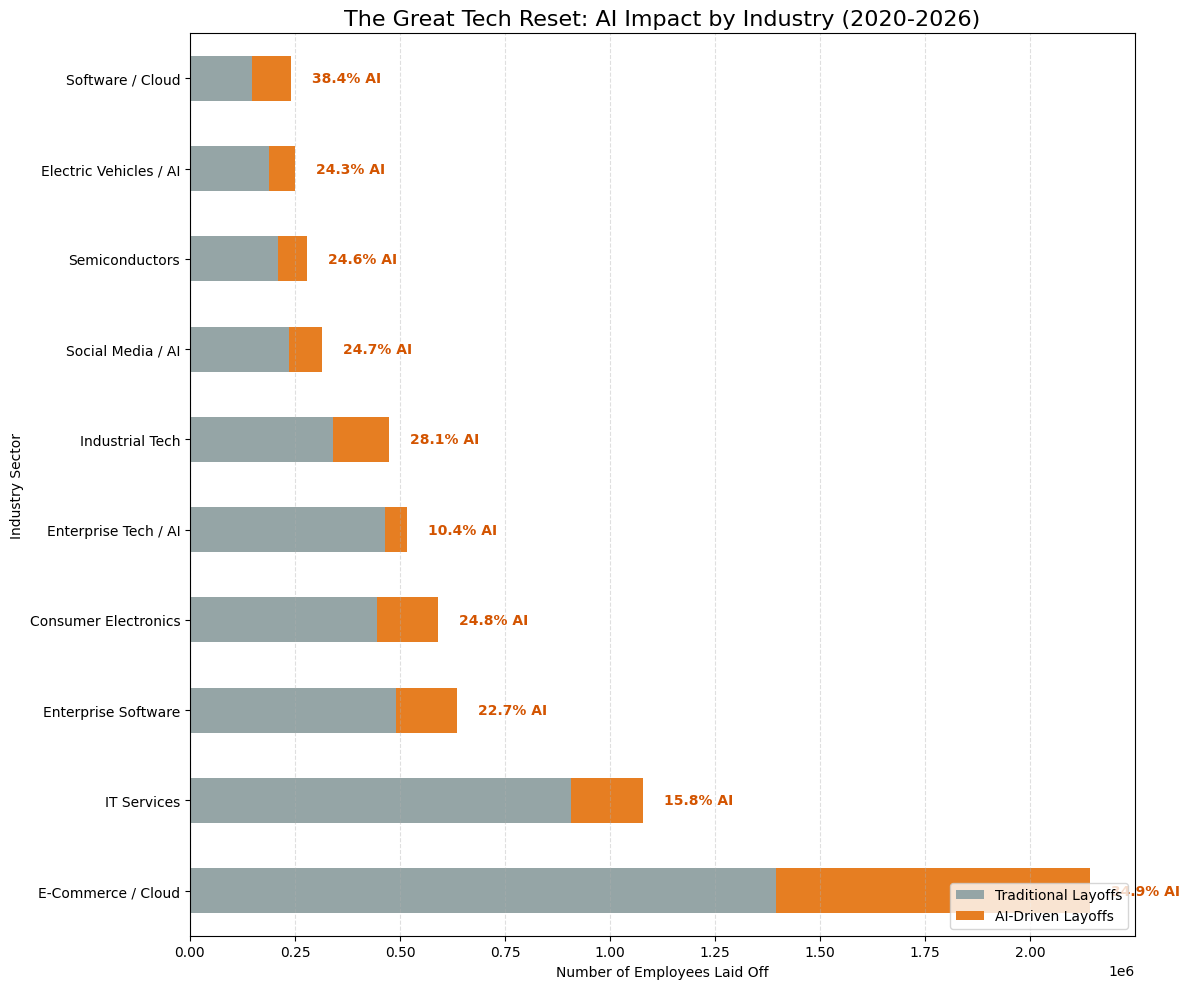

In [ ]:
#The Industry

import pandas as pd
import matplotlib.pyplot as plt

# 1. Group by Industry and the AI flag
ind_stats = df.groupby(['industry', 'is_ai_related_layoff'])['number_laid_off'].sum().unstack(fill_value=0)

# 2. Rename columns for your portfolio report
# [False] = Traditional, [True] = AI-Driven
ind_stats.columns = ['Traditional', 'AI_Driven']

# 3. Calculate Totals and Percentages
ind_stats['Total'] = ind_stats['AI_Driven'] + ind_stats['Traditional']
ind_stats['AI_Pct'] = (ind_stats['AI_Driven'] / ind_stats['Total']) * 100

# 4. Sort and get Top 10 industries
top_ind = ind_stats.sort_values('Total', ascending=False).head(10)

# 5. Plotting (Horizontal Bar Chart)
plt.figure(figsize=(12, 10))

top_ind[['Traditional', 'AI_Driven']].plot(kind='barh', stacked=True, color=['#95a5a6', '#e67e22'], ax=plt.gca())

# 6. Adding labels and style
plt.title('The Great Tech Reset: AI Impact by Industry (2020-2026)', fontsize=16)
plt.xlabel('Number of Employees Laid Off')
plt.ylabel('Industry Sector')
plt.legend(['Traditional Layoffs', 'AI-Driven Layoffs'], loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.4)

# 7. Add text for AI percentage on the right side
for i, (total, pct) in enumerate(zip(top_ind['Total'], top_ind['AI_Pct'])):
    plt.text(total + 50000, i, f'{pct:.1f}% AI', va='center', fontweight='bold', color='#d35400')

plt.tight_layout()
plt.show()

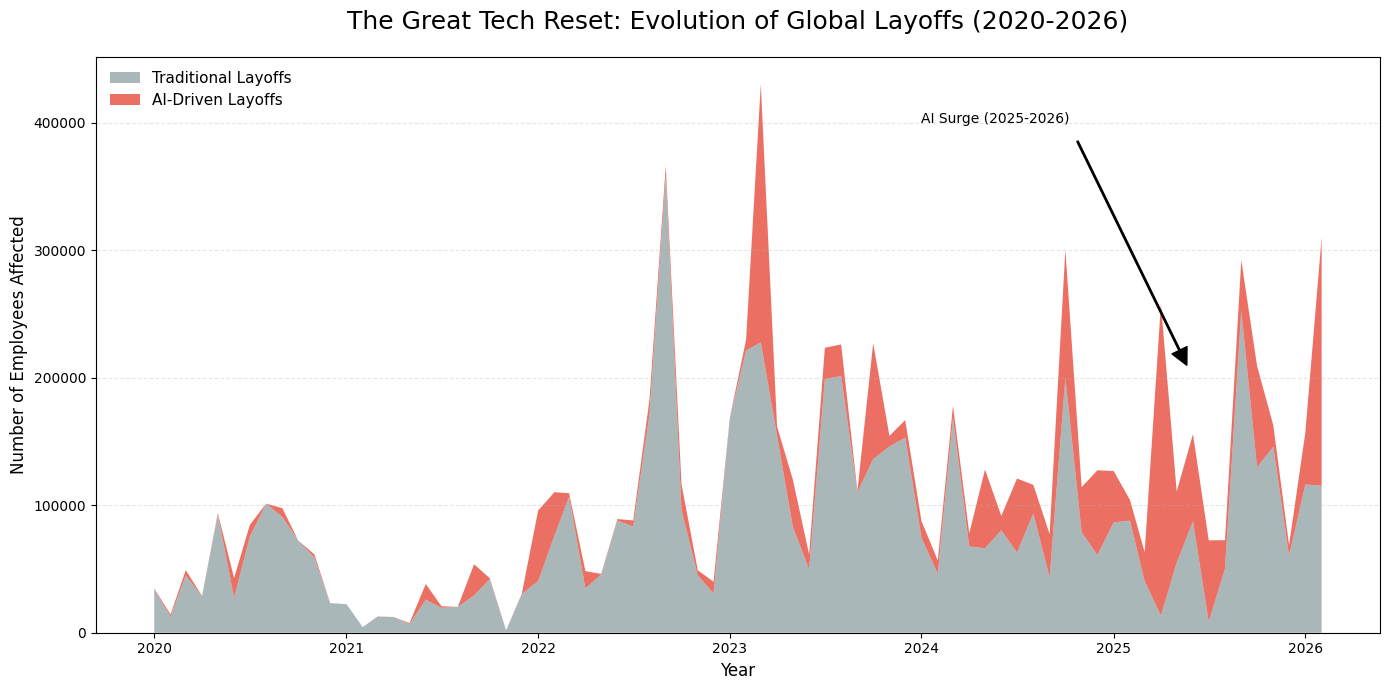

In [ ]:
#The Timeline


# 1. Group by Month and AI status
# This creates a 'Timeline' showing month-by-month totals
timeline = df.groupby([df['date_announced'].dt.to_period('M'), 'is_ai_related_layoff'])['number_laid_off'].sum().unstack(fill_value=0)
timeline.index = timeline.index.to_timestamp() # Convert period back to date for plotting

# 2. Rename columns for the legend
timeline.columns = ['Traditional', 'AI-Driven']

# 3. Create a Stacked Area Chart
plt.figure(figsize=(14, 7))
plt.stackplot(timeline.index, timeline['Traditional'], timeline['AI-Driven'],
              labels=['Traditional Layoffs', 'AI-Driven Layoffs'],
              colors=['#95a5a6', '#e74c3c'], alpha=0.8)

# 4. Styling & Professional Labels
plt.title('The Great Tech Reset: Evolution of Global Layoffs (2020-2026)', fontsize=18, pad=20)
plt.ylabel('Number of Employees Affected', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(loc='upper left', frameon=False, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Highlight the 2026 AI Surge
plt.annotate('AI Surge (2025-2026)', xy=(pd.Timestamp('2025-06-01'), 200000),
             xytext=(pd.Timestamp('2024-01-01'), 400000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.tight_layout()
plt.show()

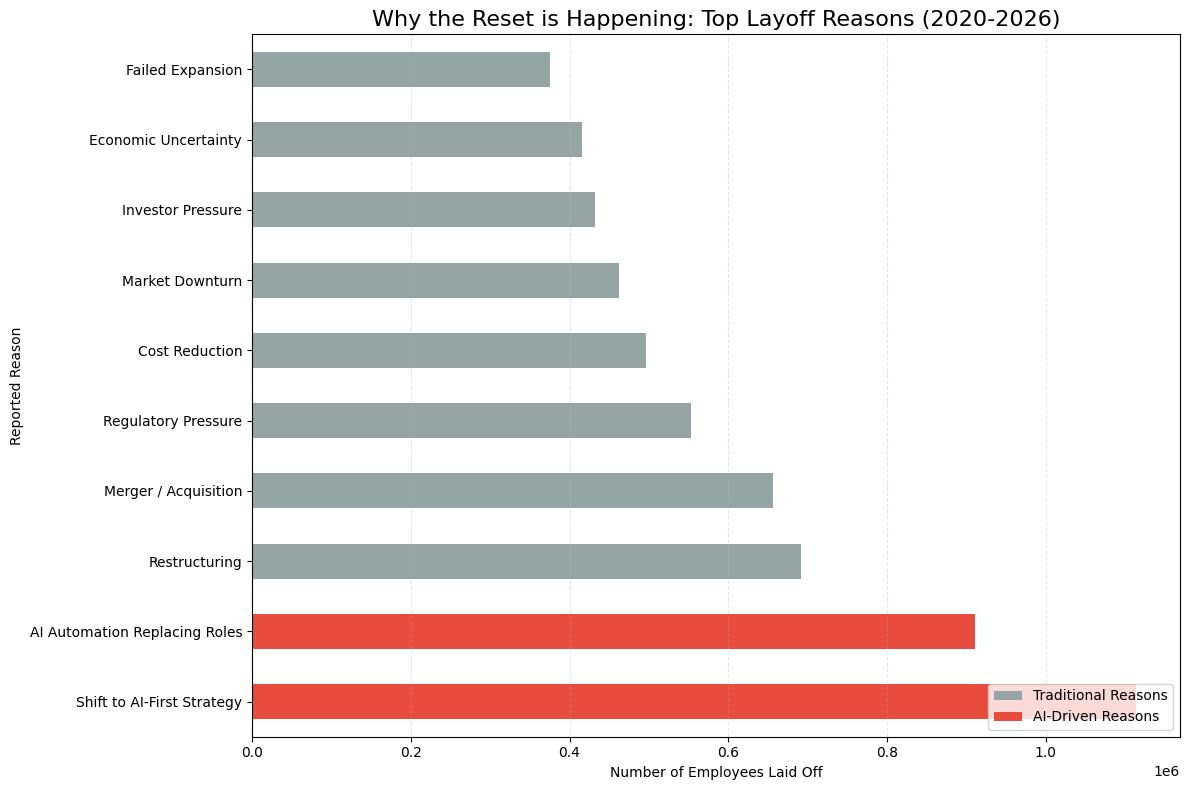

In [ ]:
#Reason

# 1. Group by Reason and AI status
grouped = df.groupby(['primary_reason', 'is_ai_related_layoff'])['number_laid_off'].sum().unstack(fill_value=0)

# 2. Rename columns for easier plotting
grouped.columns = ['Traditional', 'AI-Driven']
grouped['Total'] = grouped['Traditional'] + grouped['AI-Driven']

# 3. Sort and select top 10 reasons
top_reasons = grouped.sort_values('Total', ascending=False).head(10)

# 4. Plotting
plt.figure(figsize=(12, 8))
top_reasons[['Traditional', 'AI-Driven']].plot(kind='barh', stacked=True, color=['#95a5a6', '#e74c3c'], ax=plt.gca())

# 5. Styling
plt.title('Why the Reset is Happening: Top Layoff Reasons (2020-2026)', fontsize=16)
plt.xlabel('Number of Employees Laid Off')
plt.ylabel('Reported Reason')
plt.legend(['Traditional Reasons', 'AI-Driven Reasons'], loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Create a filter for just Amazon and Google
big_tech = df[df['company'].isin(['Amazon', 'Google'])]

# Show their most recent AI-related layoffs
print("Specific AI-Driven layoffs for Amazon & Google:")
print(big_tech[big_tech['is_ai_related_layoff'] == True][['company', 'date_announced', 'primary_reason']].head())

Specific AI-Driven layoffs for Amazon & Google:
     company date_announced                 primary_reason
280   Amazon     2022-01-22     Shift to AI-First Strategy
691   Amazon     2023-03-04     Shift to AI-First Strategy
954   Amazon     2023-10-07     Shift to AI-First Strategy
1533  Amazon     2025-04-01  AI Automation Replacing Roles
1556  Amazon     2025-04-23  AI Automation Replacing Roles
